| **Author**       | **Project Submission Date** |
|------------------|-----------------------------|
| Anoop Vijayan    | Nov 9, 2025                 |

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 100.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# Libraries to help with reading and manipulating data.
import pandas as pd
import numpy as np

# libaries to help with data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries to help with data preprocessing.
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

# Removes the limit for the number of displayed columns.
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows.
pd.set_option("display.max_rows", 200)

# Library to split data.
from sklearn.model_selection import train_test_split

# To build model for prediction.
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models.
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores.
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
    classification_report,
)

# Suppress warnings (FutureWarning).
import warnings
warnings.filterwarnings("ignore", category= FutureWarning)

## Loading the dataset

In [ ]:
# read csv to pandas dataframe
df_original = pd.read_csv('/content/Loan_Modelling.csv')
# create a working copy for the dataframe
df_working = df_original.copy()

## Data Overview

* Observations
* Sanity checks

In [ ]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df_working.head().to_markdown(index=False, numalign="left", stralign="left"))

# Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the DataFrame:")
print(df_working.tail().to_markdown(index=False, numalign="left", stralign="left"))

# Print a concise summary of the DataFrame, including the number of non-null values and data types
print("\nBasic information about the DataFrame:")
df_working.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
print(df_working.describe().to_markdown(numalign="left", stralign="left"))

First 5 rows of the DataFrame:
| ID   | Age   | Experience   | Income   | ZIPCode   | Family   | CCAvg   | Education   | Mortgage   | Personal_Loan   | Securities_Account   | CD_Account   | Online   | CreditCard   |
|:-----|:------|:-------------|:---------|:----------|:---------|:--------|:------------|:-----------|:----------------|:---------------------|:-------------|:---------|:-------------|
| 1    | 25    | 1            | 49       | 91107     | 4        | 1.6     | 1           | 0          | 0               | 1                    | 0            | 0        | 0            |
| 2    | 45    | 19           | 34       | 90089     | 3        | 1.5     | 1           | 0          | 0               | 1                    | 0            | 0        | 0            |
| 3    | 39    | 15           | 11       | 94720     | 1        | 1       | 1           | 0          | 0               | 0                    | 0            | 0        | 0            |
| 4    | 35    | 9            | 100      | 9

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [ ]:
# Determine if there is any missing data.
missing_values = df_working.isnull().sum()

# Check for nulls and NaN values in the dataset.
print('Null values ' + str(df_working.isnull().sum()) + '\n')
print('NaN values ' + str(df_working.isna().sum()) + '\n')

# Output if there are any missing data points in the dataset.
if missing_values.sum() > 0:
    print('There are missing data points in the Personal Loan dataset.')
else:
    print('There are no missing data points in the Personal Load dataset.')

Null values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

NaN values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

There are no missing data points in the Personal Load dataset.


In [ ]:
# Retrieve full statistics of the dataset.
df_working.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
# Using the describe() function with (include-'all').T can make the data more readable.
df_working.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [ ]:
# Drop the ID column from the dataset.
if 'ID' in df_working.columns:
    df_working.drop(['ID'], axis=1, inplace=True)

# Retrieve the first 5 rows of the dataset after dropping the ID column.
print('First 5 rows of the dataset after dropping the ID column:')
print(df_working.head(5).to_string(index=False))

First 5 rows of the dataset after dropping the ID column:
 Age  Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  CreditCard
  25           1      49    91107       4    1.6          1         0              0                   1           0       0           0
  45          19      34    90089       3    1.5          1         0              0                   1           0       0           0
  39          15      11    94720       1    1.0          1         0              0                   0           0       0           0
  35           9     100    94112       1    2.7          2         0              0                   0           0       0           0
  35           8      45    91330       4    1.0          2         0              0                   0           0       0           1


In [ ]:
# Find correlation between the variables in the dataset.
df_working.corr()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
Age,1.000000,0.994215,-0.055269,-0.030530,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,0.994215,1.000000,-0.046574,-0.030456,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.055269,-0.046574,1.000000,-0.030709,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIPCode,-0.030530,-0.030456,-0.030709,1.000000,0.027512,-0.012188,-0.008266,0.003614,-0.002974,0.002422,0.021671,0.028317,0.024033
Family,-0.046418,-0.052563,-0.157501,0.027512,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.052012,-0.050077,0.645984,-0.012188,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.041334,0.013152,-0.187524,-0.008266,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.012539,-0.010582,0.206806,0.003614,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal_Loan,-0.007726,-0.007413,0.502462,-0.002974,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802
Securities_Account,-0.000436,-0.001232,-0.002616,0.002422,0.019994,0.015086,-0.010812,-0.005411,0.021954,1.000000,0.317034,0.012627,-0.015028


In [ ]:
# Calculate the distribution of mortgages.
mortgage_distribution = df_working['Mortgage'].value_counts()

# Sort the distribution in descending order.
mortgage_distribution_sorted = mortgage_distribution.sort_values(ascending=False)

# Format the mortgage values into dollars.
mortgage_distribution_sorted.index = mortgage_distribution_sorted.index.map(lambda x: f'${x:,.0f}K')

# Print the distribution of mortgages.
print('Distribution of Mortgages (descending order):')
print(mortgage_distribution_sorted)

Distribution of Mortgages (descending order):
Mortgage
$0K      3462
$98K       17
$119K      16
$91K       16
$83K       16
         ... 
$452K       1
$477K       1
$432K       1
$590K       1
$541K       1
Name: count, Length: 347, dtype: int64


In [ ]:
# Create a cross-tabulation of ZIP code and Education.
zip_education_crosstab = pd.crosstab(df_working['ZIPCode'], df_working['Education'])

# Filter rows where education level count is greater than 20.
zipcode_education_sorted = zip_education_crosstab[zip_education_crosstab > 20].dropna(how='all')

# Print the cross-tabulation of ZIP code and Education.
print('Cross-tabulation of ZIP code and Education:')
print(zipcode_education_sorted.to_string())

Cross-tabulation of ZIP code and Education:
Education     1     2     3
ZIPCode                    
90089      22.0   NaN   NaN
90095      25.0   NaN  26.0
90245       NaN   NaN  21.0
91320      22.0   NaN   NaN
92037      25.0   NaN   NaN
92121      25.0   NaN   NaN
93106       NaN   NaN  22.0
93943      28.0   NaN   NaN
94025       NaN   NaN  22.0
94305      51.0  40.0  36.0
94720      68.0  49.0  52.0
95616      47.0  36.0  33.0


In [ ]:
# Check for zero or negative values in columns.
columns_to_check = ['Income', 'CCAvg', 'Mortgage','Securities_Account', 'CD_Account', 'Online', 'CreditCard']
for column in columns_to_check:
    invalid_values = df_working[df_working[column] <= 0]
    print(f'Number of rows with non-positive values in {column}: {len(invalid_values)}')

Number of rows with non-positive values in Income: 0
Number of rows with non-positive values in CCAvg: 106
Number of rows with non-positive values in Mortgage: 3462
Number of rows with non-positive values in Securities_Account: 4478
Number of rows with non-positive values in CD_Account: 4698
Number of rows with non-positive values in Online: 2016
Number of rows with non-positive values in CreditCard: 3530


In [ ]:
# Checking to see if there is a correlation between Education level and Mortgage amount.
# Calculate the correlation between 'Mortgage' and 'Education'
correlation = df_working['Mortgage'].corr(df_working['Education'])

print(f"The correlation between Mortgage and Education is: {correlation}")

The correlation between Mortgage and Education is: -0.033327124629950425


# Observations

## General Data Observations

- There are no missing data points in the **Personal Loan** dataset.  
- Memory usage of the DataFrame is **547.0 KB**.  
- **Number of Rows:** 5,000  
- **Number of Columns:** 14  
- There are no non-null values in the **Personal Loan** dataset.  
- There are **3,462 customers** that do not have a mortgage.  
- **ZIP code 94720** has the highest number of mortgage customers (**169**).  
- **ZIP code 94720** also has the highest number of educational levels:  
  - **Undergrad:** 68  
  - **Graduate:** 49  
  - **Advanced/Professional:** 52  
- **Income**, **CCAvg**, and **Education** have strong positive correlations with **Personal_Loan**, indicating they are important predictors.  
- Features like **Mortgage**, **Securities_Account**, **CD_Account**, and **Family** have moderate correlations with **Personal_Loan**, suggesting they might also be useful predictors.
# Feature Observations

- The strong correlation between **Income** and **CCAvg** indicates that both features are important and should be considered in models related to financial behavior.  
- The moderate correlations between **Income** and both **Personal_Loan** and **CCAvg** suggest that high-income individuals are good targets for personal loan offers and credit card promotions.  
- The correlation between **Securities_Account** and **CD_Account** suggests that individuals with one type of financial product are more likely to have the other.  
  - Financial institutions could consider **bundling these products** in their marketing strategies.  

---

# ZIP Code Observations

- The most common ZIP code is **94720** with **169 occurrences**, followed by **94305** with **127 occurrences**, and **95616** with **116 occurrences**.  
  - These ZIP codes represent areas with the highest concentration of individuals in the dataset.  
- The **top 20 ZIP codes** have frequencies ranging from **169 to 34**, indicating several areas with relatively high numbers of individuals.  
- The high frequencies of certain ZIP codes suggest a **concentration of individuals in specific geographical areas**.  
  - For example, ZIP codes **94720**, **94305**, and **95616** are likely significant regions in the dataset.  

### Potential Regional Bias

- The dataset appears to have a **regional bias** toward certain ZIP codes.  
  - This could be due to the sampling method or nature of data collection.  
  - It is important to consider this bias when making generalizations or building models.  
- While there is a concentration in the top ZIP codes, the presence of **20 different ZIP codes** in the top frequencies indicates a **diverse representation** of geographical areas.  
- **ZIP Code 94720** has **169 occurrences**, the highest representation — a potential key area for **targeted marketing or further analysis**.  

---

# Mortgage Observations

- The most common mortgage amount is **$0K**, with **3,462 occurrences**, indicating that a significant portion of individuals in the dataset **do not have a mortgage**.  

### Distribution of Non-Zero Mortgages

- The frequencies of **non-zero mortgage amounts** are significantly lower compared to zero mortgages.  
  - The highest frequency among non-zero mortgages is **$98K** with **17 occurrences**, followed by **$119K**, **$91K**, and **$103K**, each with **16 occurrences**.  
- There is a **long tail** of mortgage amounts with very low frequencies.  
  - Many mortgage amounts (e.g., **$281K**, **$577K**, **$302K**, **$405K**, **$541K**) have only **1 occurrence each**, indicating a wide range of sparse values.  
- The distribution is **heavily skewed toward zero mortgages**, with a rapid drop-off in frequency as the mortgage amounts increase.  
  - This suggests that most individuals either have **no mortgage** or **relatively low mortgage amounts**.  
- **Education and Mortgage** have a correlation of **-0.0333**, showing **no linear relationship** between them.  


**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

**Question 1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?**

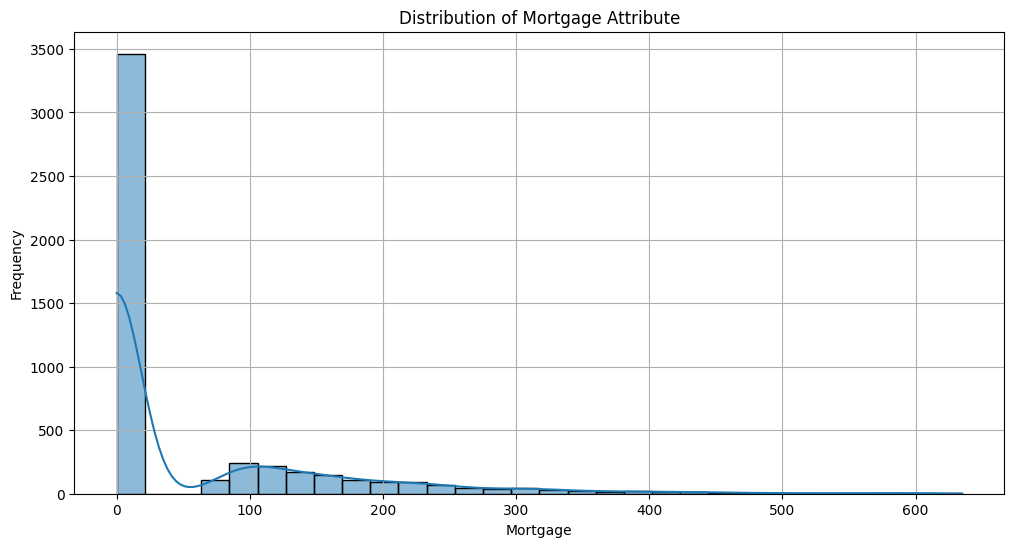

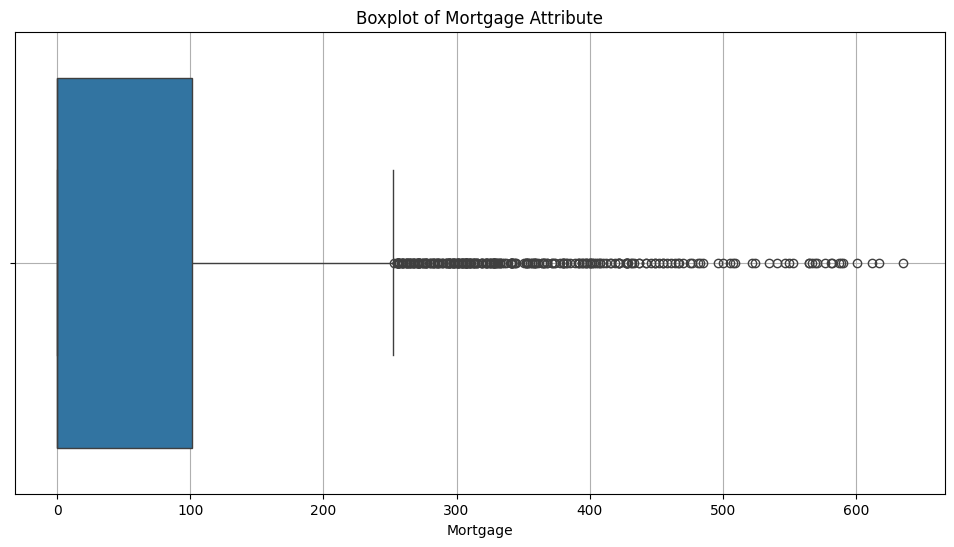

In [ ]:
# Plot the distribution of mortgage using a histogram.
plt.figure(figsize=(12, 6))
sns.histplot(df_working['Mortgage'], bins=30, kde=True)
plt.title('Distribution of Mortgage Attribute')
plt.xlabel('Mortgage')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plot the distribution of mortgage using a boxplot to identify outliers.
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_working['Mortgage'])
plt.title('Boxplot of Mortgage Attribute')
plt.xlabel('Mortgage')
plt.grid(True)
plt.show()

In [ ]:

# Number of customers with no mortgage.
no_mortgage_count = df_working[df_working['Mortgage'] == 0].shape[0]

# Total number of customers.
total_customers = df_working.shape[0]

# Percentage of customers with no mortgage.
percentage_no_mortgage = (no_mortgage_count / total_customers) * 100

print(f"Number of customers with no mortgage: {no_mortgage_count:,}")
print(f"Total number of customers: {total_customers:,}")
print(f'Percentage of customers with no mortgage: {percentage_no_mortgage:.2f}%')

Number of customers with no mortgage: 3,462
Total number of customers: 5,000
Percentage of customers with no mortgage: 69.24%


# Observations

- **69.24%** of customers do **not have a mortgage ($0)**.  
  - This represents a **significant portion** of the overall customer base.  

### Recommendation
- **Market to these customers** with a **special program offering low introductory rates** to capture new business.


**Question 2. How many customers have credit cards?**

In [ ]:
# Total number of customers.
total_customers = df_working.shape[0]

# Number of customers with credit cards from All Life Bank and other banks.
other_cc = df_working[df_working['CreditCard'] == 1].shape[0]
all_life_bank_cc = df_working[df_working['CreditCard'] == 0].shape[0]

print(f'Number of customers with All Life Bank credit card: {all_life_bank_cc:,}')
print(f'Number of customers using a credit card at another bank: {other_cc:,}')
print(f'Total number of customers: {total_customers:,}')
print(f'Percentage of customers with credit cards: {(other_cc / total_customers * 100):.2f}%')

Number of customers with All Life Bank credit card: 3,530
Number of customers using a credit card at another bank: 1,470
Total number of customers: 5,000
Percentage of customers with credit cards: 29.40%


# Observations

- **29.4%** of customers have credit cards from other banks.  

### Recommendation
- **Market a special program with low introductory APR** to capture business away from competitors.


**Question 3. What are the attributes that have a strong correlation with the target attribute (personal loan)?**

In [ ]:
# Find the highest correlated feature pairs in the personal_loan_df DataFrame.
correlation_matrix = df_working.corr(numeric_only=True)

# Unstack the correlation matrix.
correlation_pairs = correlation_matrix.unstack()

# Filter out self-correlations.
filtered_pairs = correlation_pairs[correlation_pairs != 1]

# Sort the correlations in descending order.
sorted_pairs = filtered_pairs.sort_values(ascending=False)

# Display the correlated feature pairs.
highest_correlated_features = sorted_pairs.head(10)
print(highest_correlated_features)

Age                 Experience            0.994215
Experience          Age                   0.994215
CCAvg               Income                0.645984
Income              CCAvg                 0.645984
Personal_Loan       Income                0.502462
Income              Personal_Loan         0.502462
CCAvg               Personal_Loan         0.366889
Personal_Loan       CCAvg                 0.366889
Securities_Account  CD_Account            0.317034
CD_Account          Securities_Account    0.317034
dtype: float64


In [ ]:
# Calculate the correlation matrix.
correlation_matrix = df_working.corr(numeric_only=True)

# Get correlations with the target attribute (Personal Loan).
correlations_with_target = correlation_matrix['Personal_Loan'].drop('Personal_Loan')

# Identify attributes with strong correlations (absolute value > 0.5)
strong_correlations = correlations_with_target[correlations_with_target.abs() > 0.5]

# Print attributes with strong correlations with the target attribute.
print("Attributes with strong correlation with the target attribute Personal_Loan):")
for attribute, correlation in strong_correlations.items():
    print(f"{attribute} with Correlation of {correlation}.")

Attributes with strong correlation with the target attribute Personal_Loan):
Income with Correlation of 0.502462292494936.


# Observations

## Correlation Data

| Feature Pair | Correlation Value | Interpretation |
|---------------|------------------:|----------------|
| **Age and Experience** | **0.994215** | There is an extremely high positive correlation between Age and Experience. This is expected as older individuals generally have more work experience. |
| **Income and CCAvg** | **0.645984** | There is a strong positive correlation between Income and CCAvg (Credit Card Average). This suggests that individuals with higher incomes tend to have higher average credit card spending. |
| **Income and Personal_Loan** | **0.502462** | There is a moderate positive correlation between Income and Personal_Loan. This indicates that individuals with higher incomes are more likely to have personal loans. |
| **CCAvg and Personal_Loan** | **0.366889** | There is a moderate positive correlation between CCAvg and Personal_Loan. This suggests that individuals with higher average credit card spending are somewhat more likely to have personal loans. |
| **Securities_Account and CD_Account** | **0.317034** | There is a moderate positive correlation between Securities_Account and CD_Account. This indicates that individuals with a securities account are somewhat more likely to have a certificate of deposit (CD) account. |


**Question 4. How does a customer's interest in purchasing a loan vary with their age?**

Loan Interest by Age Group
------------------------------------------------------------
Age Group: 20-29, Proportion: 0.10040983606557377
Age Group: 30-39, Proportion: 0.10184442662389735
Age Group: 40-49, Proportion: 0.09307875894988067
Age Group: 50-59, Proportion: 0.08845577211394302
Age Group: 60-69, Proportion: 0.10237388724035608


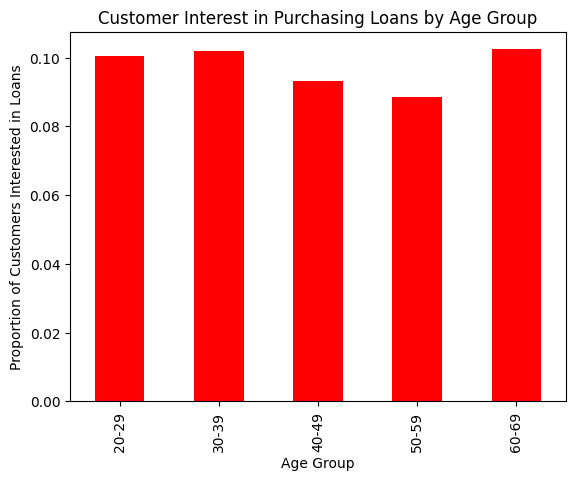

In [ ]:
# Create age bins.
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69']
df_working['AgeGroup'] = pd.cut(df_working['Age'], bins=bins, labels=labels, right=False)

# Calculate the proportion of customers interested in loans for each age group.
loan_interest_by_age = df_working.groupby('AgeGroup')['Personal_Loan'].mean()

# Print proportion of customers interested in loans by age group.
print("Loan Interest by Age Group")
print("-" * 60)
for age_group, proportion in loan_interest_by_age.items():
    print(f"Age Group: {age_group}, Proportion: {proportion}")

# Visualize results.
loan_interest_by_age.plot(kind='bar', color='red')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Customers Interested in Loans')
plt.title('Customer Interest in Purchasing Loans by Age Group')
plt.show()

# Observations

- There is **no significant difference** in personal loan interest across different age groups.  

## Customers by Age Group and Loan Interest

| Age Group | Interest in Personal Loan |
|------------|---------------------------|
| 20–29      | ~10.04%                  |
| 30–39      | ~10.18%                  |
| 40–49      | ~9.31%                   |
| 50–59      | ~8.85%                   |
| 60–69      | ~10.24%                  |


**Question 5. How does a customer's interest in purchasing a loan vary with their education?**

Loan Interest by Education Level
------------------------------------------------------------
Education Level: 1, Proportion: 0.044370229007633585
Education Level: 2, Proportion: 0.12972202423378476
Education Level: 3, Proportion: 0.13657561625582945


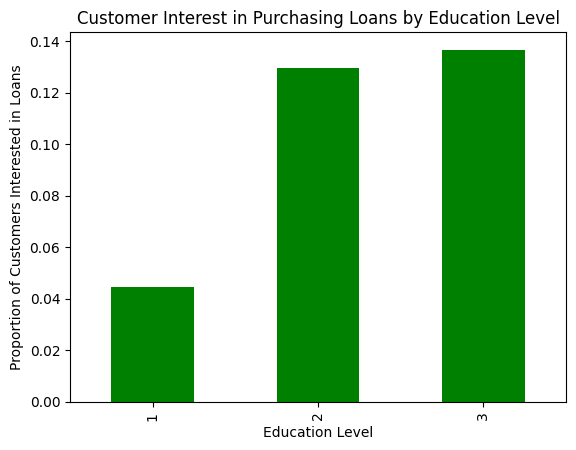

In [ ]:
# Calculate the proportion of customers interested in loans for each education level.
loan_interest_by_education = df_working.groupby('Education')['Personal_Loan'].mean()

# Print proportion of customers interested in loans by education level.
# 1: Undergrad; 2: Graduate; 3: Advanced/Professional
print("Loan Interest by Education Level")
print("-" * 60)
for education_level, proportion in loan_interest_by_education.items():
    print(f"Education Level: {education_level}, Proportion: {proportion}")

# Visualize results.
loan_interest_by_education.plot(kind='bar', color='green')
plt.xlabel('Education Level')
plt.ylabel('Proportion of Customers Interested in Loans')
plt.title('Customer Interest in Purchasing Loans by Education Level')
plt.show()

# Observations

- **Undergraduates (4.44%)** represent a very low percentage of individuals interested in loans.  
  - This could be because these individuals may already have **student debt** and are **not interested in additional credit card expenses** or **high APR** loans.  
  - **Recommendation:** Introduce a **special loan program** with **low APR** or **no interest rate penalty** for an initial period to attract this segment.

- **Graduates (12.97%)** and **Advanced/Professional degree holders (13.66%)** show a **higher interest in personal loans**.  
  - This may be attributed to their **greater financial stability** and **better money management experience**.


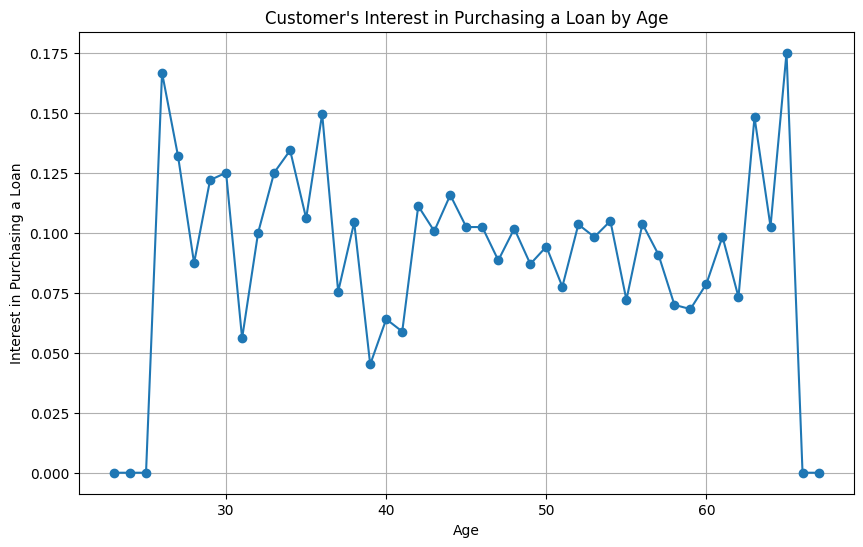

In [ ]:
# Group by age and calculate the mean interest in purchasing a loan.
age_interest_df = df_working.groupby('Age')['Personal_Loan'].mean().reset_index()

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(age_interest_df['Age'], age_interest_df['Personal_Loan'], marker='o')

# Add labels and title.
plt.title("Customer's Interest in Purchasing a Loan by Age")
plt.xlabel('Age')
plt.ylabel('Interest in Purchasing a Loan')
plt.grid(True)
plt.show()

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

**Missing value treatment**

In [ ]:
# Determine if there is any missing data.
missing_values = df_working.isnull().sum()

# Check for nulls and NaN values in the dataset.
print('Null values ' + str(df_working.isnull().sum()) + '\n')
print('NaN values ' + str(df_working.isna().sum()) + '\n')

# Output if there are any missing data points in the dataset.
if missing_values.sum() > 0:
    print('There are missing data points in the Personal Loan dataset.')
else:
    print('There are no missing data points in the Personal Load dataset.')

Null values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

NaN values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

There are no missing data points in the Personal Load dataset.


**Feature engineering**

In [ ]:
# Change categorical features to 'category'.
category_cols = [
    'Education',
    'Personal_Loan',
    'Securities_Account',
    'CD_Account',
    'Online',
    'CreditCard',
    'ZIPCode',
]
df_working[category_cols] = df_working[category_cols].astype('category')

# Check for changes in the data types.
categorical_columns = df_working.select_dtypes(include=['category']).columns.tolist()

# Print the categorical columns.
print('Categorical columns:', categorical_columns)

Categorical columns: ['ZIPCode', 'Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


**Outlier detection and treatment**

In [ ]:
def detect_anomalous_values(df):
    anomalous_values = {}
    for column in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        if not outliers.empty:
            anomalous_values[column] = outliers[column].values
    return anomalous_values

# Detect anomalous values in the df_working.
anomalous_values = detect_anomalous_values(df_working)

# Print the anomalous values.
for column, values in anomalous_values.items():
    print(f"Anomalous values in column '{column}': {values}")

Anomalous values in column 'Income': [193 194 190 188 195 191 200 205 204 195 192 194 202 195 200 193 192 195
 191 188 191 190 190 194 195 192 190 195 191 192 195 192 193 190 198 201
 200 188 192 190 194 201 191 191 188 203 189 193 190 204 198 201 201 191
 191 195 190 188 190 195 195 205 198 190 191 191 195 194 194 202 191 199
 203 188 224 188 189 191 190 195 193 204 194 195 191 188 195 188 193 199
 188 199 194 201 195 218]
Anomalous values in column 'CCAvg': [ 8.9   8.1   5.7   8.    5.7   5.6   7.2   7.4   7.5   6.5   6.5   7.8
  7.9   6.8   7.4   7.5   7.9   6.2   5.5   6.9   7.5   7.3   6.1   6.33
  6.6   5.3   7.5   6.8   7.    6.6   6.3   7.5   5.7   8.3   5.5   6.9
  6.1   6.    8.    6.8   6.33  7.8   7.2   6.5   6.8   6.    7.2   8.6
  6.9   6.1   7.8   6.    7.6   7.4   6.1   7.    8.1   6.9   6.4   6.
  7.6   6.3   7.6  10.    6.    5.9   8.1   5.4   8.8   5.4   6.33  8.1
  8.8   5.7   7.6   7.3   7.    5.7   6.1   6.9   6.8   5.6   7.    6.5
  7.4   7.8   8.    7.    8.    

**Preparing data for modeling**

In [ ]:
numerical_cols = df_working.select_dtypes(include=['int64', 'float64']).columns

outlier_percentages = {}

for col in numerical_cols:
    Q1 = df_working[col].quantile(0.25)
    Q3 = df_working[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers for the current column
    outliers = df_working[(df_working[col] < lower_bound) | (df_working[col] > upper_bound)]

    # Calculate percentage of outliers
    percentage = (len(outliers) / len(df_working)) * 100
    outlier_percentages[col] = percentage

print("Percentage of Outliers per Numerical Column (using IQR method):")
for col, percentage in outlier_percentages.items():
    print(f"{col}: {percentage:.2f}%")

Percentage of Outliers per Numerical Column (using IQR method):
ID: 0.00%
Age: 0.00%
Experience: 0.00%
Income: 1.92%
Family: 0.00%
CCAvg: 6.48%
Mortgage: 5.82%


In [ ]:
# Find number of unique ZIP codes.
print('Number of unique ZIP codes:', df_working['ZIPCode'].nunique())

# Calculate the distribution of ZIP codes.
zipcode_distribution = df_working['ZIPCode'].value_counts()

# Print first 20 ZIP codes.
print('Distribution of ZIP codes:')
print(zipcode_distribution.head(20))

Number of unique ZIP codes: 467
Distribution of ZIP codes:
ZIPCode
94720    169
94305    127
95616    116
90095     71
93106     57
93943     54
92037     54
91320     53
94025     52
91711     52
92093     51
90245     50
90024     50
91330     46
90089     46
94304     45
92121     45
94143     37
94608     34
95051     34
Name: count, dtype: int64


In [ ]:
# Convert ZIPCode to string.
df_working['ZIPCode'] = df_working['ZIPCode'].astype(str)

# Extract the first two digits of ZIPCode and count unique values.
num_unique_zip_codes = df_working['ZIPCode'].str[0:2].nunique()

# Print the number of unique ZIP codes.
print('Number of unique values if we take first two digits of ZIPCode:', num_unique_zip_codes)

# Convert ZIPCode to categorical.
df_working['ZIPCode'] = df_working['ZIPCode'].astype('category')

Number of unique values if we take first two digits of ZIPCode: 7


In [ ]:
# Check for unique values in the dataset.
df_working.nunique()

,0
ID,5000
Age,45
Experience,47
Income,162
ZIPCode,467
Family,4
CCAvg,108
Education,3
Mortgage,347
Personal_Loan,2


In [ ]:
# Find the unqiue numbers and count of unique values in the Experience column.
print('Unique values for Experience: ' + str(df_working['Experience'].unique()) + '\n')
print('Number of unique values in Experience:', df_working['Experience'].nunique())

Unique values for Experience: [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]

Number of unique values in Experience: 47


In [ ]:
# Check for negative values in the Experience column.
print('Current nagative values: ' + str(df_working[df_working['Experience'] < 0]['Experience'].unique()))
print('Number of negative values: ' + str(df_working[df_working['Experience'] < 0]['Experience'].nunique()))

# Replace negative values in the Experience column.
df_working['Experience'].replace(-1, 1, inplace=True)
df_working['Experience'].replace(-2, 2, inplace=True)
df_working['Experience'].replace(-3, 3, inplace=True)

print('Unique values for Experience: \n' + str(df_working['Experience'].unique()) + '\n')
print('Number of unique values in Experience:', df_working['Experience'].nunique())

Current nagative values: [-1 -2 -3]
Number of negative values: 3
Unique values for Experience: 
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 34  0 38 40 33  4 42 43]

Number of unique values in Experience: 44


In [ ]:
# Check for negative values in the Experience column.
print('Current values: ' + str(df_working['Education'].unique()))
print('Number of values: ' + str(df_working['Education'].nunique()))

Current values: [1, 2, 3]
Categories (3, int64): [1, 2, 3]
Number of values: 3


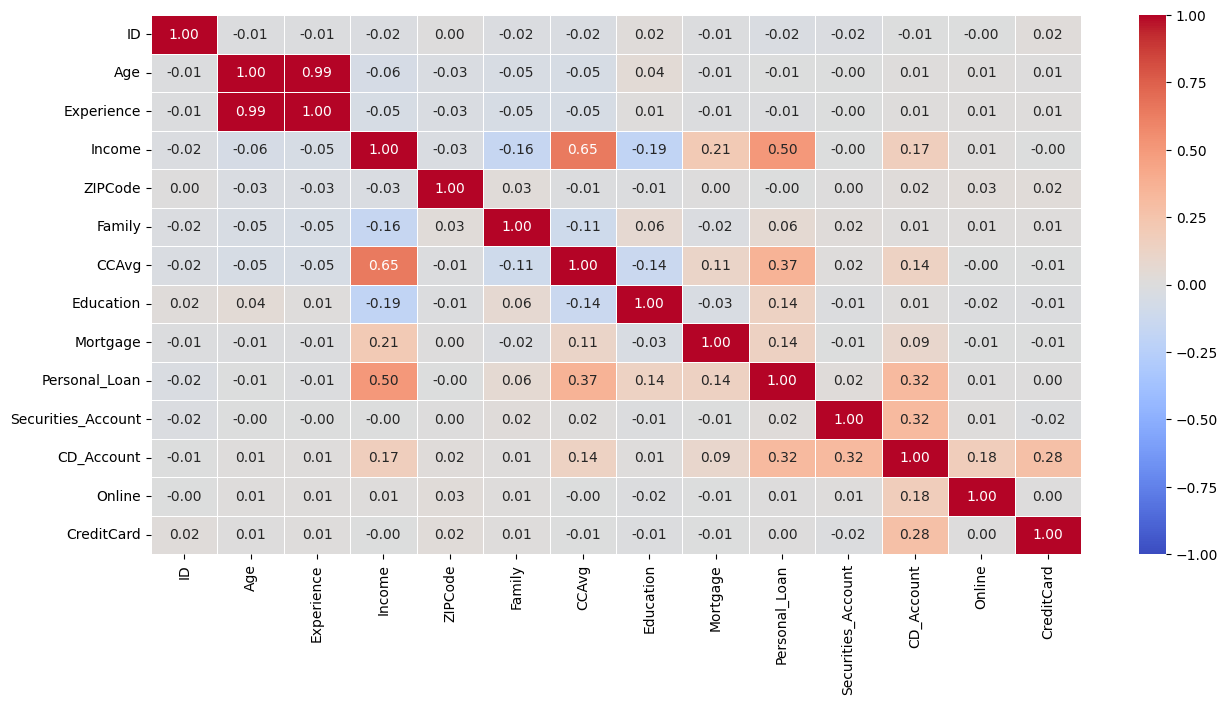

In [ ]:
# Plot the correlation matrix as a heatmap.
plt.figure(figsize=(15, 7))
sns.heatmap(df_working.corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

**Preparing data for modeling**

In [ ]:
# Dropping Experience as it is perfectly correlated with Age, 0.99
X = df_working.drop(['Personal_Loan', 'Experience'], axis=1)
Y = df_working['Personal_Loan']

X = pd.get_dummies(X, columns=['ZIPCode', 'Education'], drop_first=True)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [ ]:
# Print the shape of the training set.
print('Shape of Training set : ', X_train.shape)

# Print the shape of the test set.
print('Shape of test set : ', X_test.shape)

# Print a blank line for better readability.
print()

# Print the percentage distribution of classes in the training set.
print('Percentage of classes in training set:')
print(y_train.value_counts(normalize=True).to_dict())

# Print a blank line for better readability.
print()

# Print the percentage distribution of classes in the test set.
print('Percentage of classes in test set:')
print(y_test.value_counts(normalize=True).to_dict())

Shape of Training set :  (3500, 478)
Shape of test set :  (1500, 478)

Percentage of classes in training set:
{0: 0.9054285714285715, 1: 0.09457142857142857}

Percentage of classes in test set:
{0: 0.9006666666666666, 1: 0.09933333333333333}


## Model Building

In [ ]:
# Encode categorical variables using one-hot encoding.
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Ensure the training and test sets have the same columns after encoding.
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Initialize the DecisionTreeClassifier with the Gini impurity criterion and a fixed random state.
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=1,
    # max_depth=5,            # Limit the maximum depth of the tree
    # min_samples_split=10,   # Minimum number of samples required to split an internal node
    # min_samples_leaf=5,     # Minimum number of samples required to be at a leaf node
    # max_leaf_nodes=20       # Maximum number of leaf nodes
)

# Fit the model on the encoded training data.
model.fit(X_train_encoded, y_train)

DecisionTreeClassifier(random_state=1)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3169
           1       1.00      1.00      1.00       331

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500



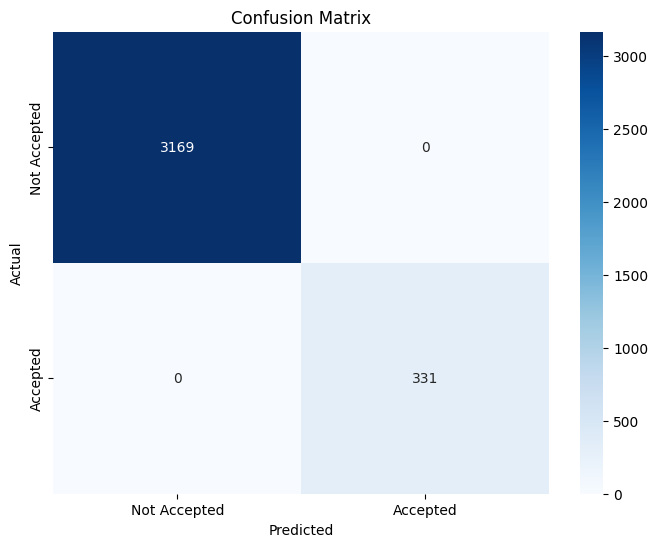

In [ ]:
# Predict on the training data.
y_train_pred = model.predict(X_train_encoded)

# Calculate accuracy.
accuracy = accuracy_score(y_train, y_train_pred)
print(f'Accuracy: {accuracy:.2f}')

# Calculate precision.
precision = precision_score(y_train, y_train_pred)
print(f'Precision: {precision:.2f}')

# Calculate recall.
recall = recall_score(y_train, y_train_pred)
print(f'Recall: {recall:.2f}')

# Calculate F1 score.
f1 = f1_score(y_train, y_train_pred)
print(f'F1 Score: {f1:.2f}')

# Print classification report.
print('Classification Report:')
print(classification_report(y_train, y_train_pred))

# Calculate confusion matrix.
conf_matrix = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Accepted', 'Accepted'], yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Model Evaluation Criterion

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    print("Training Set Evaluation:")
    y_train_pred = model.predict(X_train)
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
    print(f"Precision: {precision_score(y_train, y_train_pred):.2f}")
    print(f"Recall: {recall_score(y_train, y_train_pred):.2f}")
    print(f"F1 Score: {f1_score(y_train, y_train_pred):.2f}")

    print("\nTest Set Evaluation:")
    y_test_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_test_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_test_pred):.2f}")

# Call the function to evaluate the model
evaluate_model(model, X_train_encoded, y_train, X_test_encoded, y_test)

Training Set Evaluation:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Test Set Evaluation:
Accuracy: 0.98
Precision: 0.96
Recall: 0.87
F1 Score: 0.91


## Model Performance Improvement

In [ ]:
# Function for model performance evaluation.

def model_performance_classification_sklearn(model, X, y):
    # Predict the labels for the input features X using the provided model.
    y_pred = model.predict(X)

    # Calculate the accuracy of the model.
    accuracy = accuracy_score(y, y_pred)

    # Calculate the precision of the model.
    precision = precision_score(y, y_pred)

    # Calculate the recall of the model.
    recall = recall_score(y, y_pred)

    # Calculate the F1 score of the model.
    f1 = f1_score(y, y_pred)

    # Return a dictionary containing the performance metrics.
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}

In [ ]:
# Check performance on training data.
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train_encoded, y_train
)
decision_tree_perf_train

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

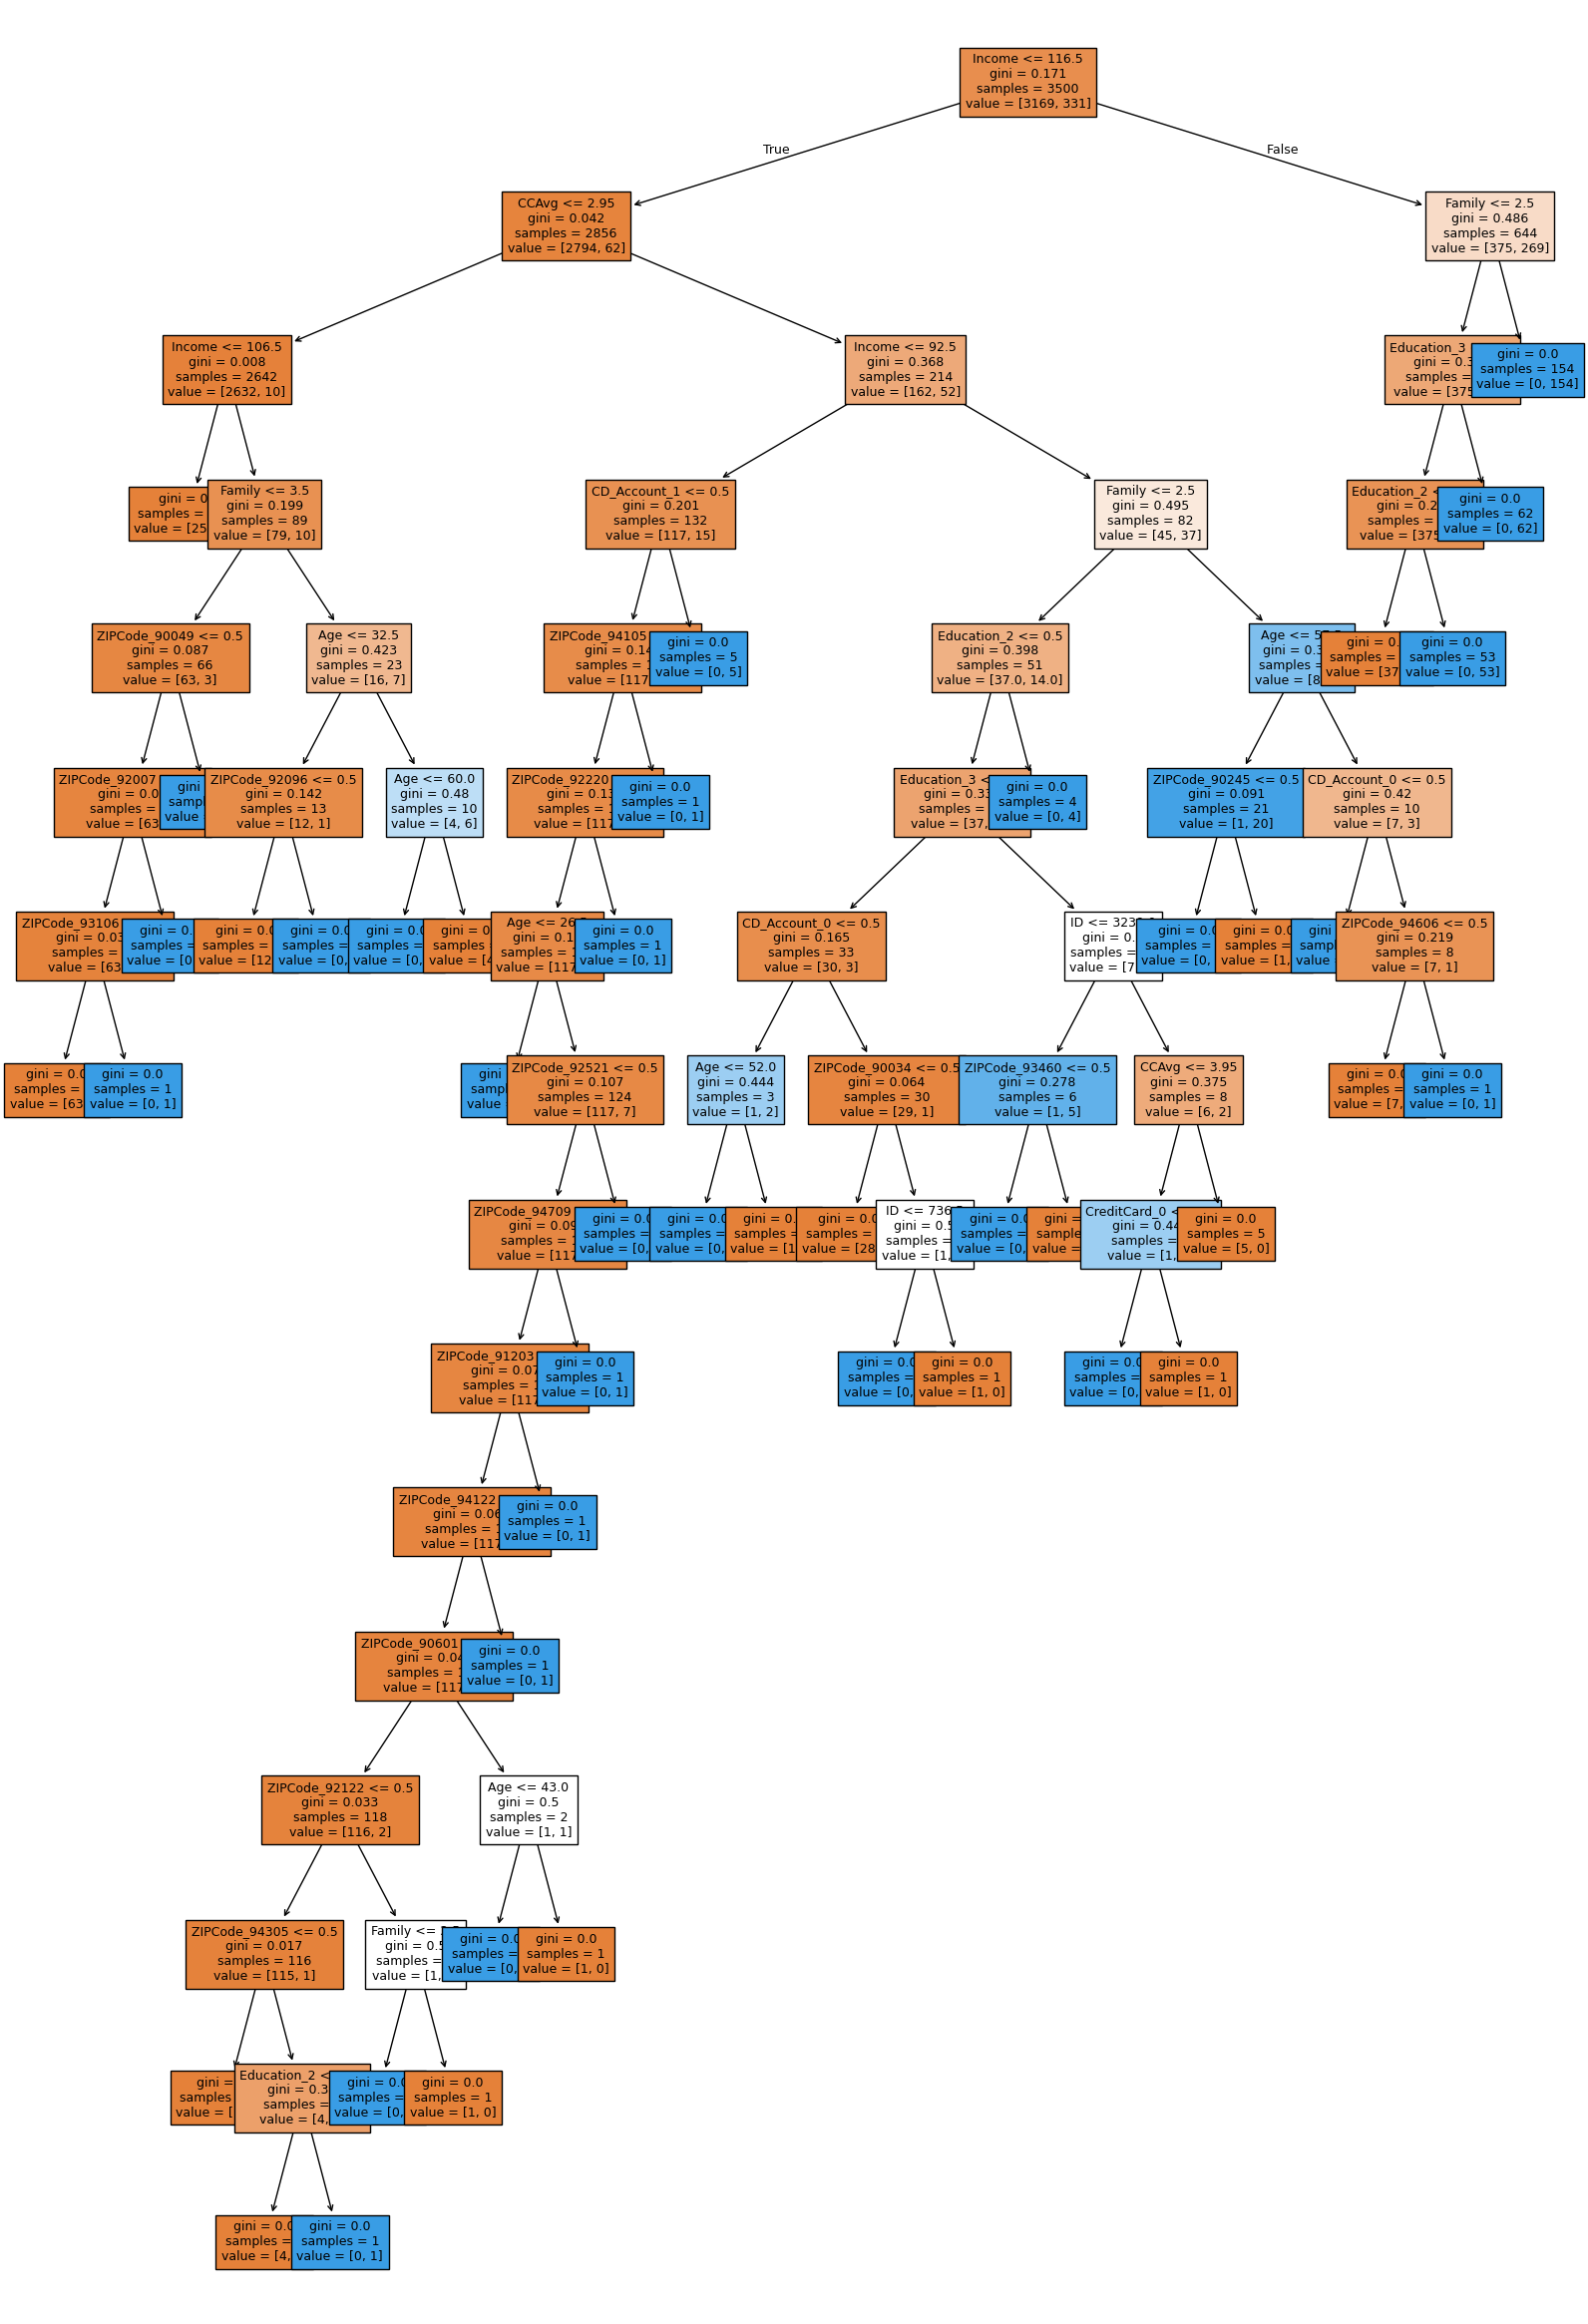

In [ ]:
# Visualize the decision tree.
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
    model, # type: ignore
    feature_names=list(X_train_encoded.columns),  # type: ignore
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# Add arrows to the decision tree split if they are missing.
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Assign the feature importances to a variable.
importances = model.feature_importances_

# Sort indices in descending order.
indices = np.argsort(importances)[::-1]

# Create a DataFrame for feature importances.
feature_importances_df = pd.DataFrame({
    'Feature': [list(X_train_encoded.columns)[i] for i in indices],  # type: ignore
    'Importance': importances[indices]
})

# Print the DataFrame.
print(feature_importances_df)

           Feature  Importance
0           Income    0.297816
1           Family    0.248530
2      Education_2    0.165238
3      Education_3    0.144207
4            CCAvg    0.040577
..             ...         ...
477  ZIPCode_94501    0.000000
478  ZIPCode_94507    0.000000
479  ZIPCode_94509    0.000000
480  ZIPCode_94521    0.000000
481  ZIPCode_94132    0.000000

[482 rows x 2 columns]


Accuracy: 0.98
Precision: 0.96
Recall: 0.87
F1 Score: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1351
           1       0.96      0.87      0.91       149

    accuracy                           0.98      1500
   macro avg       0.97      0.93      0.95      1500
weighted avg       0.98      0.98      0.98      1500



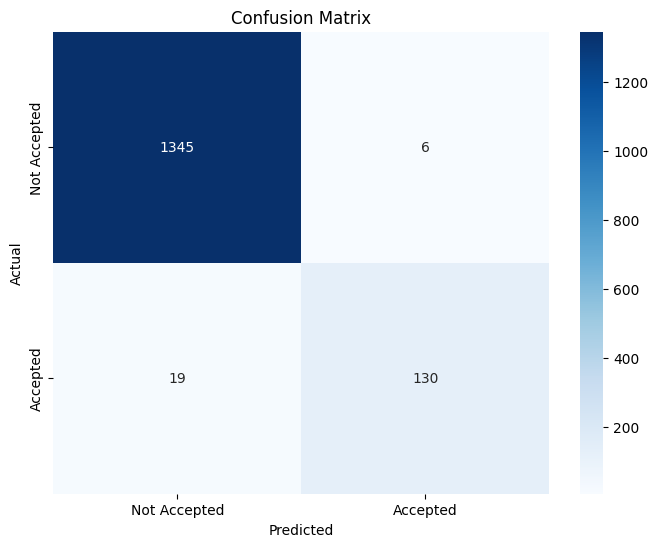

In [ ]:
# Check model performance on the test data.

# Predict on the test data.
y_test_pred = model.predict(X_test_encoded) # type: ignore

# Calculate accuracy.
accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy: {accuracy:.2f}')

# Calculate precision.
precision = precision_score(y_test, y_test_pred)
print(f'Precision: {precision:.2f}')

# Calculate recall.
recall = recall_score(y_test, y_test_pred)
print(f'Recall: {recall:.2f}')

# Calculate F1 score.
f1 = f1_score(y_test, y_test_pred)
print(f'F1 Score: {f1:.2f}')

# Print classification report.
print('Classification Report:')
print(classification_report(y_test, y_test_pred))

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Accepted', 'Accepted'], yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Check performance on the test data.
decision_tree_perf_test = model_performance_classification_sklearn(model, X_test_encoded, y_test) # type: ignore
decision_tree_perf_test

{'Accuracy': 0.9833333333333333,
 'Precision': 0.9558823529411765,
 'Recall': 0.87248322147651,
 'F1 Score': 0.9122807017543859}

**Pre-Pruning**

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Hyperparameter grid.
parameters = {
    "max_depth": np.arange(6, 15),
    "min_samples_leaf": [1, 2, 5, 7, 10],
    "max_leaf_nodes": [2, 3, 5, 10],
}

# Type of scoring used to compare parameter combinations.
acc_scorer = make_scorer(recall_score)

# Run the grid search.
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train_encoded, y_train) # type: ignore

# Set the clf to the best combination of parameters.
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train_encoded, y_train) # type: ignore

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=10,
                       min_samples_leaf=10, random_state=1)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3169
           1       1.00      1.00      1.00       331

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500



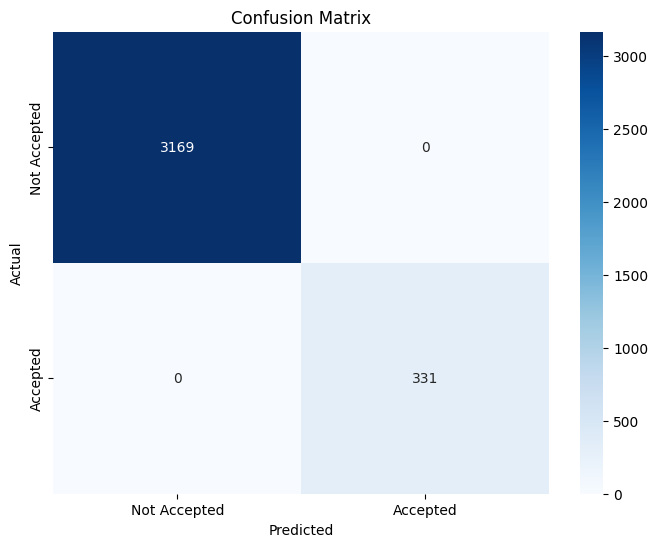

In [ ]:
# Check model performance on the test data.

# Predict on the test data.
y_test_pred = model.predict(X_train_encoded) # type: ignore

# Calculate accuracy.
accuracy = accuracy_score(y_train, y_train_pred) # type: ignore
print(f'Accuracy: {accuracy:.2f}')

# Calculate precision.
precision = precision_score(y_train, y_train_pred) # type: ignore
print(f'Precision: {precision:.2f}')

# Calculate recall.
recall = recall_score(y_train, y_train_pred) # type: ignore
print(f'Recall: {recall:.2f}')

# Calculate F1 score.
f1 = f1_score(y_train, y_train_pred) # type: ignore
print(f'F1 Score: {f1:.2f}')

# Print classification report.
print('Classification Report:')
print(classification_report(y_train, y_train_pred)) # type: ignore

# Calculate confusion matrix.
conf_matrix = confusion_matrix(y_train, y_train_pred) # type: ignore

# Plot confusion matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Accepted', 'Accepted'], yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Check performance on the tuned data.
decision_tree_tune_perf_train = model_performance_classification_sklearn(estimator, X_train_encoded, y_train) # type: ignore
decision_tree_tune_perf_train

{'Accuracy': 0.9877142857142858,
 'Precision': 0.996551724137931,
 'Recall': 0.8731117824773413,
 'F1 Score': 0.9307568438003221}

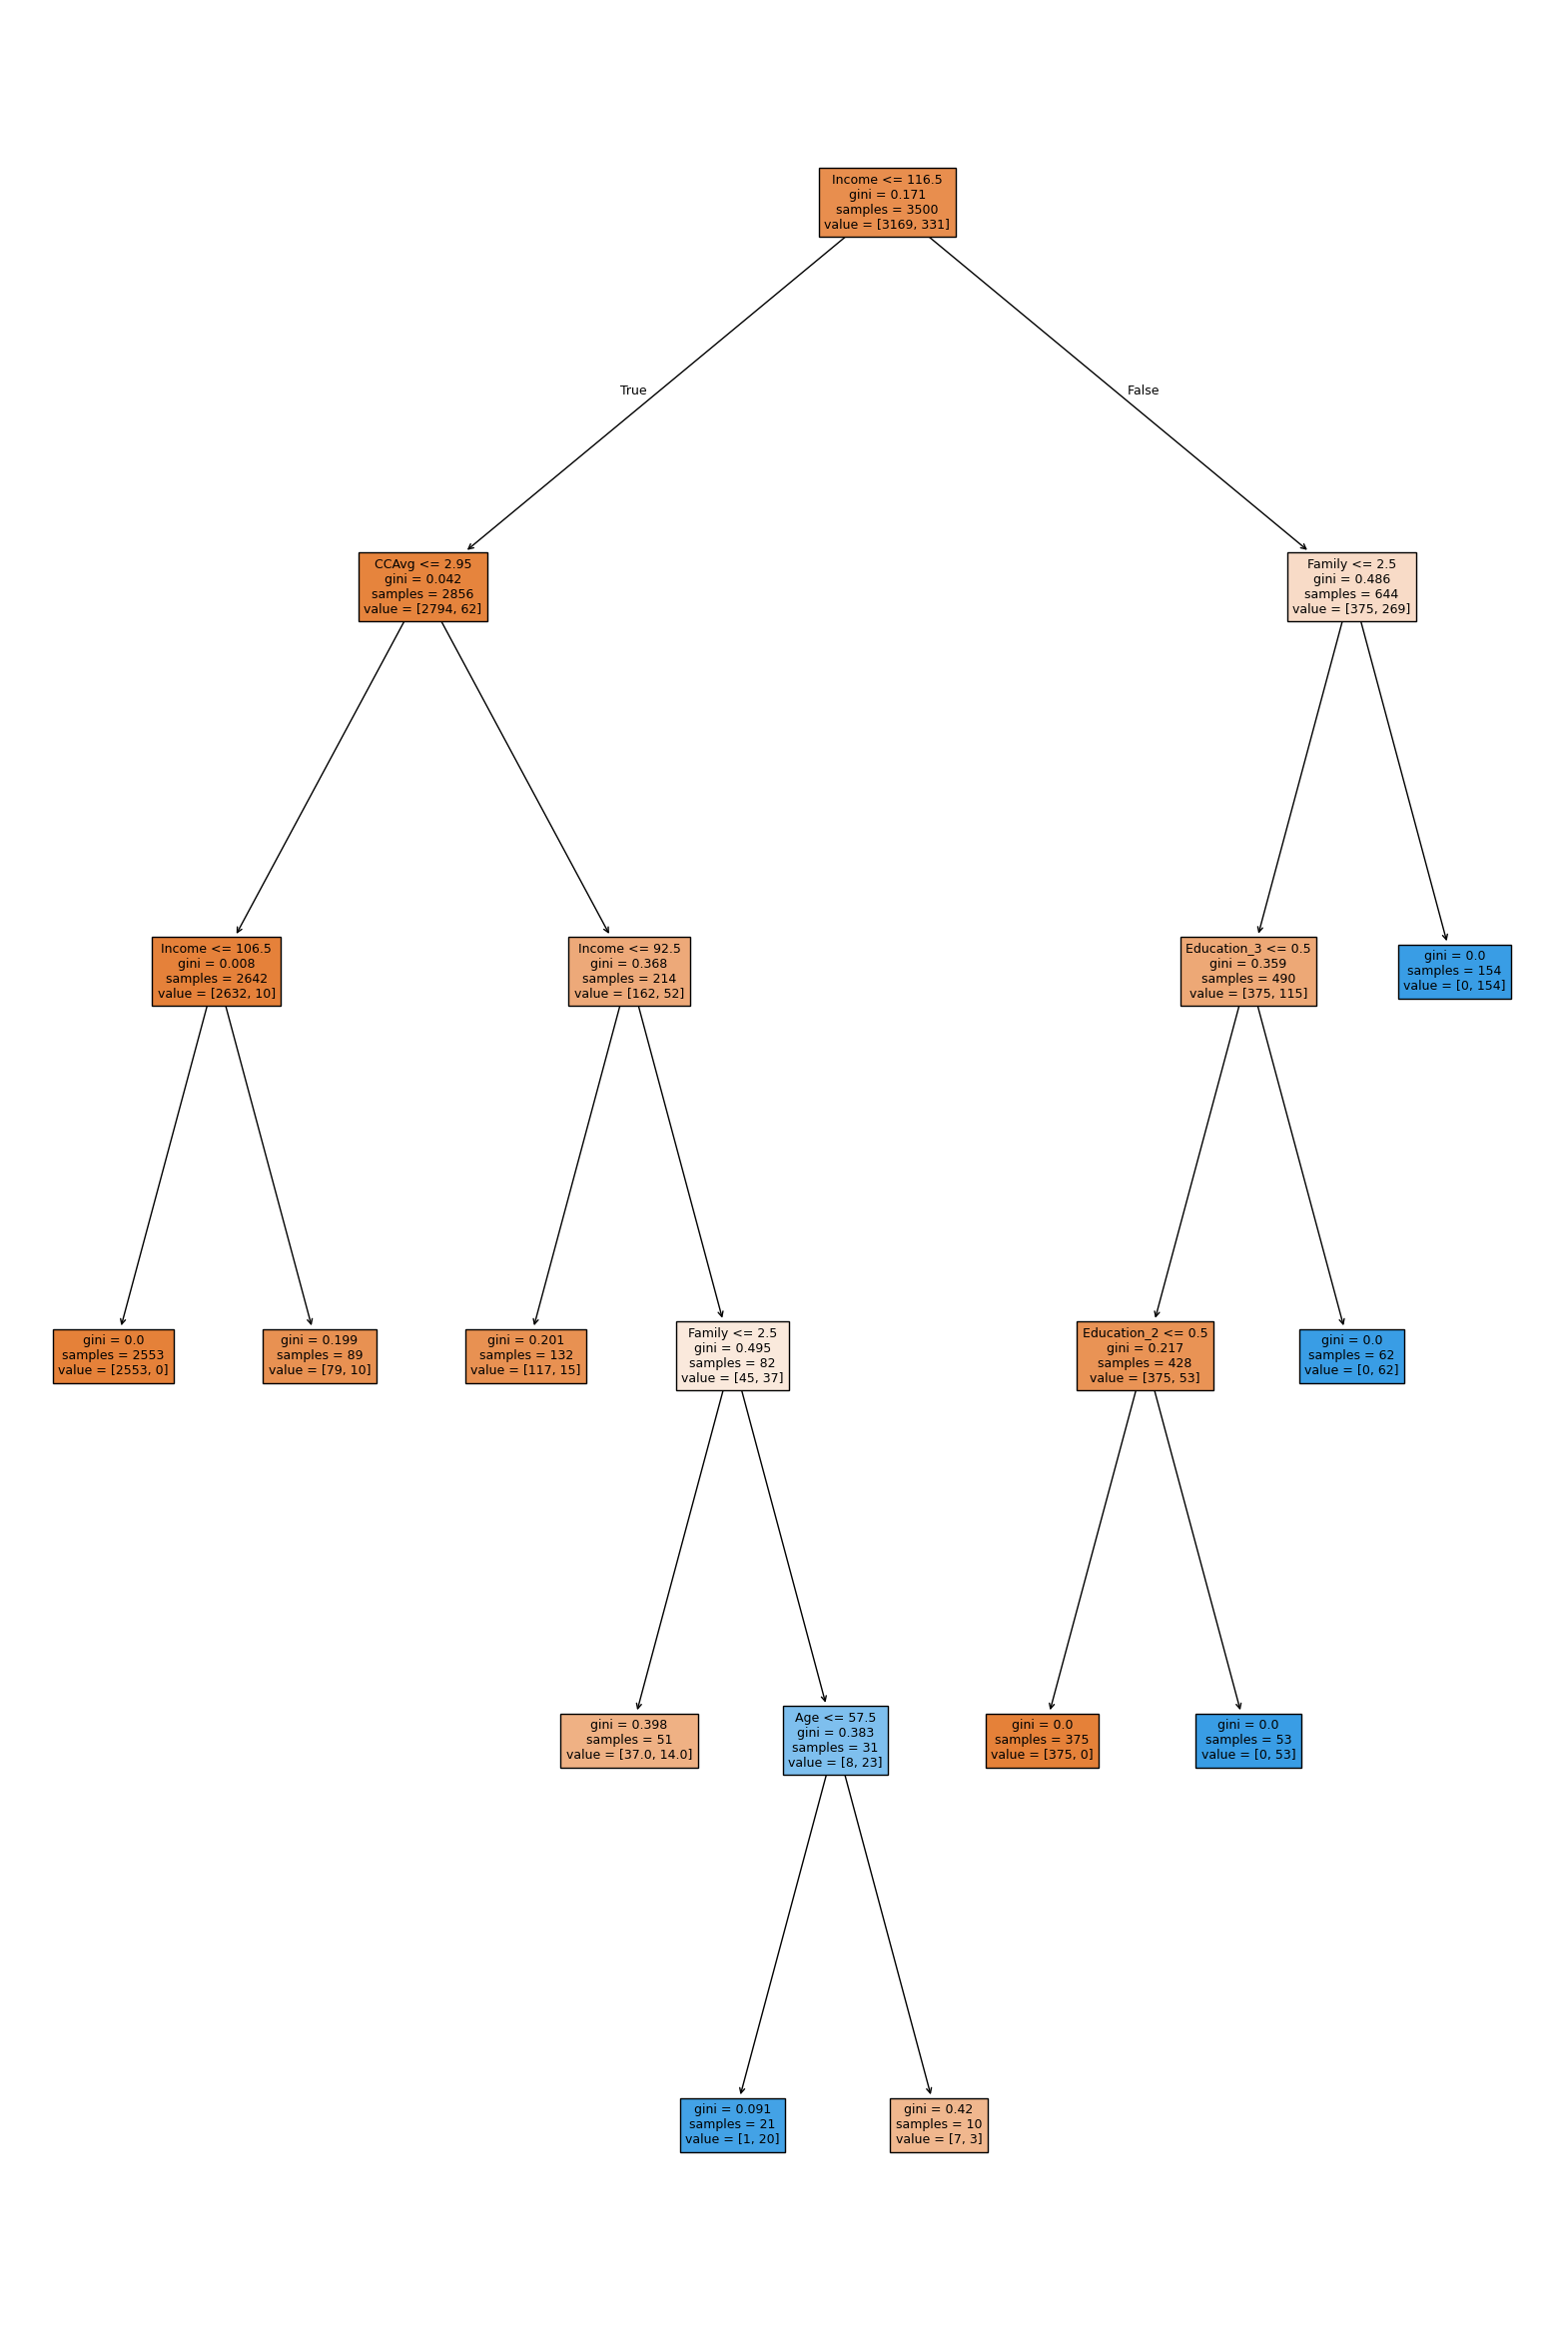

In [ ]:
# Visualize the decision tree.
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
    estimator,
    feature_names=list(X_train_encoded.columns), # type: ignore
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# Add arrows to the decision tree split if they are missing.
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

Accuracy: 0.99
Precision: 1.00
Recall: 0.87
F1 Score: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3169
           1       1.00      0.87      0.93       331

    accuracy                           0.99      3500
   macro avg       0.99      0.94      0.96      3500
weighted avg       0.99      0.99      0.99      3500



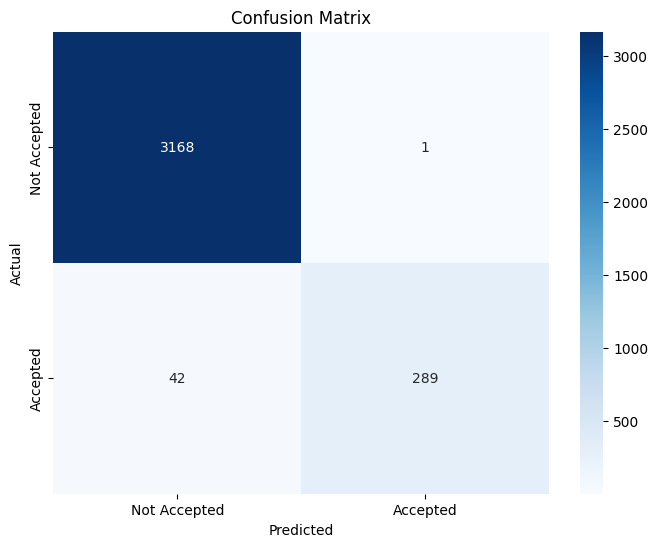

In [ ]:
# Predict on the training data.
y_train_pred = estimator.predict(X_train_encoded) # type: ignore

# Calculate accuracy.
accuracy = accuracy_score(y_train, y_train_pred)
print(f'Accuracy: {accuracy:.2f}')

# Calculate precision.
precision = precision_score(y_train, y_train_pred)
print(f'Precision: {precision:.2f}')

# Calculate recall.
recall = recall_score(y_train, y_train_pred)
print(f'Recall: {recall:.2f}')

# Calculate F1 score.
f1 = f1_score(y_train, y_train_pred)
print(f'F1 Score: {f1:.2f}')

# Print classification report.
print('Classification Report:')
print(classification_report(y_train, y_train_pred))

# Calculate confusion matrix.
conf_matrix = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Accepted', 'Accepted'], yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Generate a text report showing the rules of the decision tree.
tree_rules = tree.export_text(estimator, feature_names=list(X_train_encoded.columns), show_weights=True) # type: ignore
print(tree_rules)

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- weights: [79.00, 10.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- weights: [117.00, 15.00] class: 0
|   |   |--- Income >  92.50
|   |   |   |--- Family <= 2.50
|   |   |   |   |--- weights: [37.00, 14.00] class: 0
|   |   |   |--- Family >  2.50
|   |   |   |   |--- Age <= 57.50
|   |   |   |   |   |--- weights: [1.00, 20.00] class: 1
|   |   |   |   |--- Age >  57.50
|   |   |   |   |   |--- weights: [7.00, 3.00] class: 0
|--- Income >  116.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- weights: [375.00, 0.00] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- weights: [0.00, 53.00] class: 1
|   |   |--- Education_3 >  0.50
|   |   |   |--- weights: [0.00, 62.00] class: 1
|   |--- Family >  2.

In [ ]:
# Check performance on the test data.
decision_tree_tune_perf_test = model_performance_classification_sklearn(model, X_test_encoded, y_test)
decision_tree_tune_perf_test

{'Accuracy': 0.9833333333333333,
 'Precision': 0.9558823529411765,
 'Recall': 0.87248322147651,
 'F1 Score': 0.9122807017543859}

In [ ]:
# Compute the pruning path for the decision tree using minimal cost-complexity pruning.
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train_encoded, y_train) # type: ignore
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Create a DataFrame and sort by ccp_alphas in descending order.
pruning_path_df = pd.DataFrame(path)
pruning_path_df_sorted = pruning_path_df.sort_values(by='ccp_alphas', ascending=False)

# Show sorted pruning path values.
pruning_path_df_sorted

,ccp_alphas,impurities
25,0.047088,0.171255
24,0.039216,0.124167
23,0.025146,0.084951
22,0.006473,0.034659
21,0.003294,0.028187
20,0.002407,0.024893
19,0.002333,0.022486
18,0.001647,0.020153
17,0.001305,0.018505
16,0.000940,0.017200


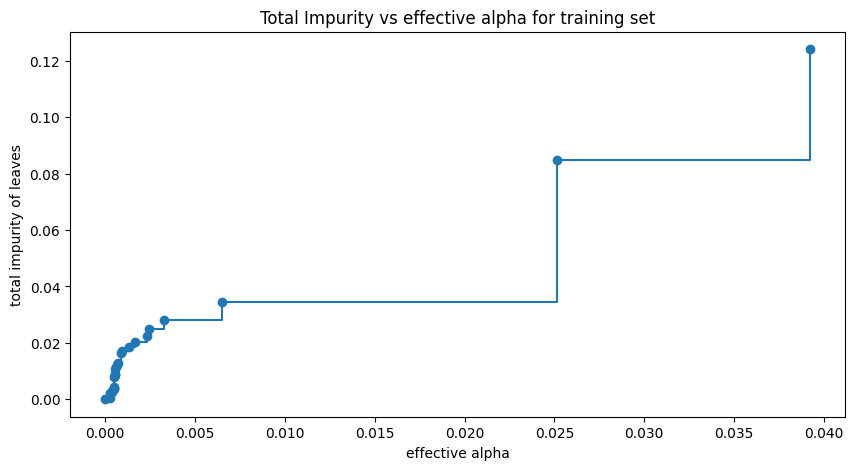

In [ ]:
# Create a figure and an axis object with a specified size.
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the relationship between effective alpha and total impurity of leaves
# Use markers "o" and draw style "steps-post" for the plot.
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the label for the x-axis.
ax.set_xlabel("effective alpha")

# Set the label for the y-axis.
ax.set_ylabel("total impurity of leaves")

# Set the title of the plot.
ax.set_title("Total Impurity vs effective alpha for training set")

# Display the plot.
plt.show()

In [ ]:
# Initialize an empty list to store the decision tree classifiers.
clfs = []

# Iterate over the list of ccp_alpha values.
for ccp_alpha in ccp_alphas:
    # Initialize a DecisionTreeClassifier with the current ccp_alpha value
    # and a fixed random state.
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)

    # Fit the decision tree classifier on the training data.
    clf.fit(X_train_encoded, y_train) # type: ignore

    # Append the fitted classifier to the list.
    clfs.append(clf)

# Print the number of nodes in the last tree and the corresponding ccp_alpha value.
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.04708834100596766


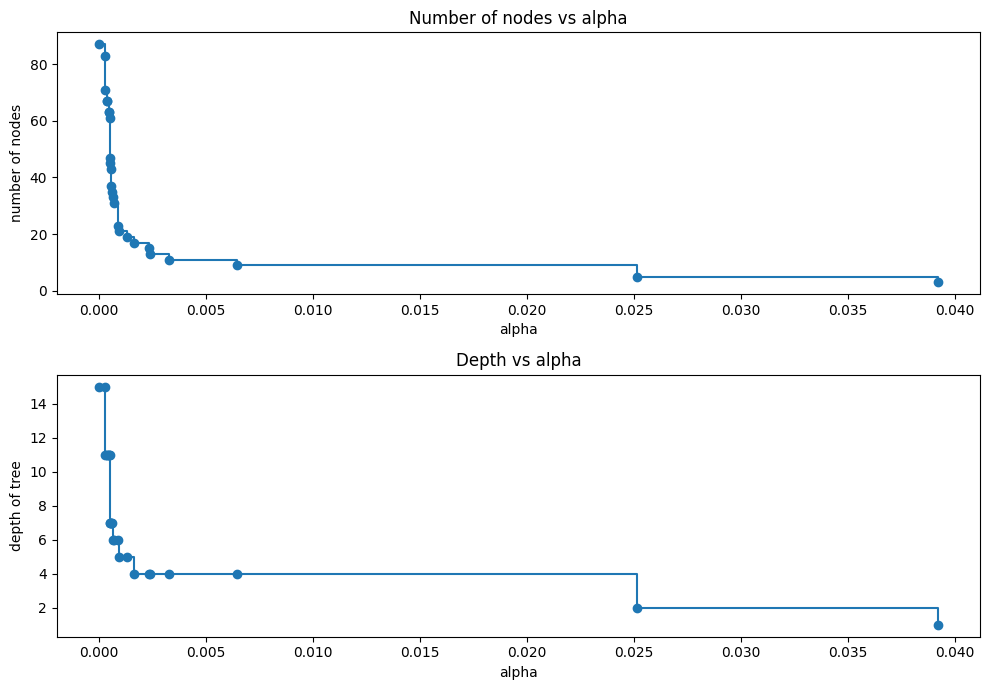

In [ ]:
# Remove the last element from the list of classifiers and ccp_alphas.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Calculate the number of nodes for each classifier.
node_counts = [clf.tree_.node_count for clf in clfs]

# Calculate the depth of each classifier.
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure with two subplots, arranged vertically, with a specified size.
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes vs alpha on the first subplot.
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

# Plot the depth of the tree vs alpha on the second subplot.
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")

# Adjust the layout to prevent overlap.
fig.tight_layout()

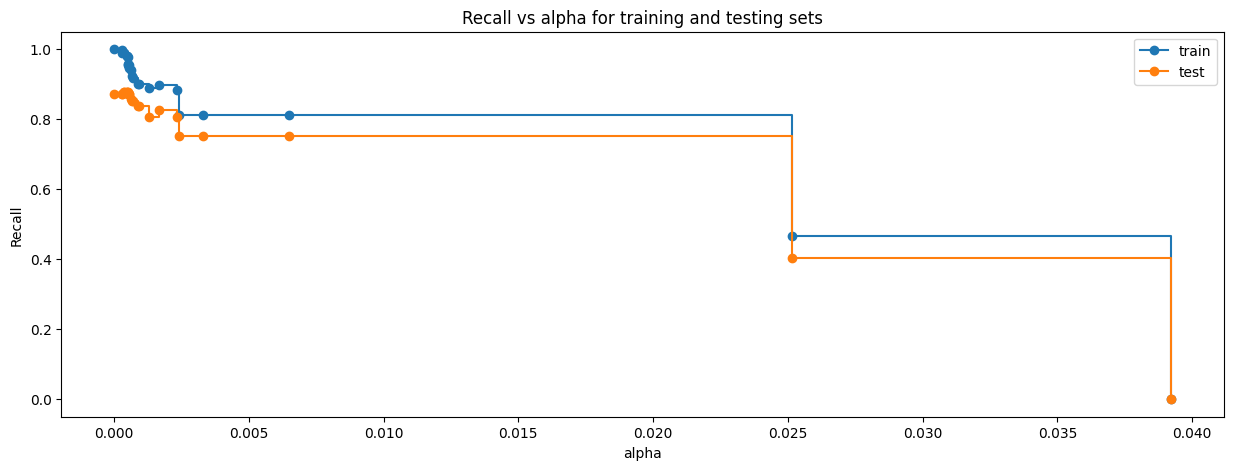

In [ ]:
# Initialize an empty list to store recall scores for the training set.
recall_train = []

# Iterate over the list of classifiers.
for clf in clfs:
    # Predict the labels for the training set using the current classifier.
    pred_train = clf.predict(X_train_encoded)

    # Calculate the recall score for the training set.
    values_train = recall_score(y_train, pred_train)

    # Append the recall score to the recall_train list.
    recall_train.append(values_train)

# Initialize an empty list to store recall scores for the test set.
recall_test = []

# Iterate over the list of classifiers.
for clf in clfs:
    # Predict the labels for the test set using the current classifier.
    pred_test = clf.predict(X_test_encoded) # type: ignore

    # Calculate the recall score for the test set.
    values_test = recall_score(y_test, pred_test)

    # Append the recall score to the recall_test list.
    recall_test.append(values_test)
# Create a figure and an axis object with a specified size.
fig, ax = plt.subplots(figsize=(15, 5))

# Set the label for the x-axis.
ax.set_xlabel("alpha")

# Set the label for the y-axis.
ax.set_ylabel("Recall")

# Set the title of the plot.
ax.set_title("Recall vs alpha for training and testing sets")

# Plot the recall scores for the training set vs alpha.
# Use markers "o" and draw style "steps-post" for the plot.
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")

# Plot the recall scores for the test set vs alpha.
# Use markers "o" and draw style "steps-post" for the plot.
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")

# Add a legend to the plot.
ax.legend()

# Display the plot.
plt.show()

In [ ]:
# Find the index of the classifier with the highest recall score on the test set.
index_best_model = np.argmax(recall_test)

# Select the classifier corresponding to the best recall score.
best_model = clfs[index_best_model]

# Print the details of the best model.
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0003809523809523809),
                       random_state=1)


**Post-Pruning**

In [ ]:
# Initialize the DecisionTreeClassifier with the last ccp_alpha value from the pruning path,
# set class weights to handle class imbalance, and set a random state for reproducibility.
estimator_2 = DecisionTreeClassifier(
    ccp_alpha=ccp_alphas[-1],  # Use the last ccp_alpha value.
    class_weight={0: 0.15, 1: 0.85},  # Set class weights.
    random_state=1  # Set random state for reproducibility.
)

# Fit the classifier on the training data.
estimator_2.fit(X_train_encoded, y_train) # type: ignore

DecisionTreeClassifier(ccp_alpha=np.float64(0.03921599695778932),
                       class_weight={0: 0.15, 1: 0.85}, random_state=1)

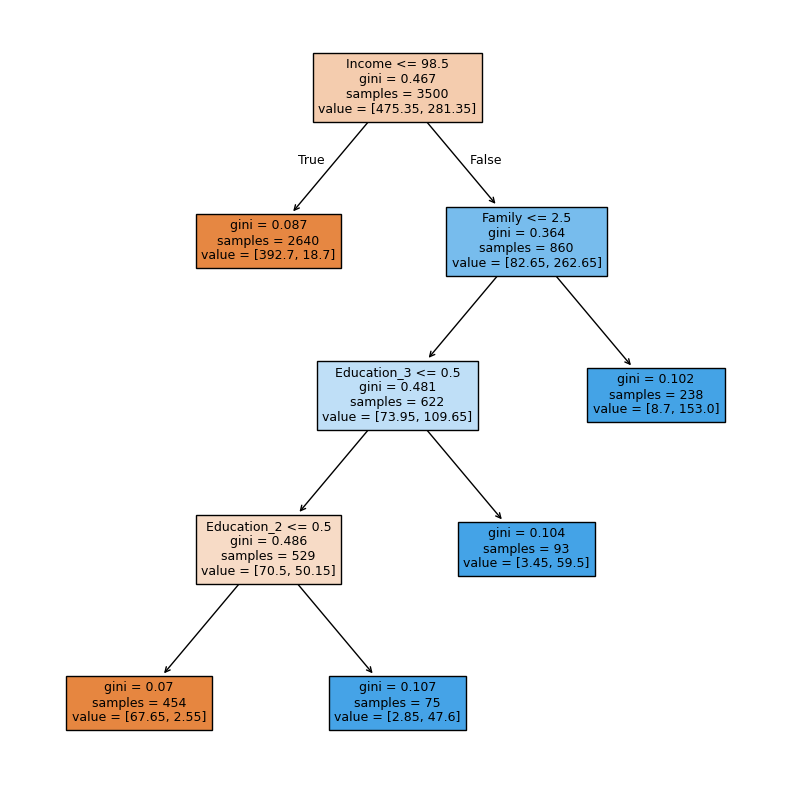

In [ ]:
# Visualize the decision tree.
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    estimator_2,
    feature_names=list(X_train_encoded.columns), # type: ignore
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# Add arrows to the decision tree split if they are missing.
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Generate a text report showing the rules of the decision tree.
tree_rules = tree.export_text(estimator_2, feature_names=list(X_train_encoded.columns),show_weights=True) # type: ignore
print(tree_rules)

|--- Income <= 98.50
|   |--- weights: [392.70, 18.70] class: 0
|--- Income >  98.50
|   |--- Family <= 2.50
|   |   |--- Education_3 <= 0.50
|   |   |   |--- Education_2 <= 0.50
|   |   |   |   |--- weights: [67.65, 2.55] class: 0
|   |   |   |--- Education_2 >  0.50
|   |   |   |   |--- weights: [2.85, 47.60] class: 1
|   |   |--- Education_3 >  0.50
|   |   |   |--- weights: [3.45, 59.50] class: 1
|   |--- Family >  2.50
|   |   |--- weights: [8.70, 153.00] class: 1



In [ ]:
# Check performance on the test data.
decision_tree_tune_post_train = model_performance_classification_sklearn(model, X_train_encoded, y_train) # type: ignore
decision_tree_tune_post_train

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0}

In [ ]:
# Assign the feature importances to a variable.
importances = estimator_2.feature_importances_

# Sort indices in descending order.
indices = np.argsort(importances)[::-1]

# Create a DataFrame for feature importances.
feature_importances_df = pd.DataFrame({
    'Feature': [list(X_train_encoded.columns)[i] for i in indices], # type: ignore
    'Importance': importances[indices]
})

# Print the DataFrame.
print(feature_importances_df)

           Feature  Importance
0           Income    0.675027
1      Education_2    0.169826
2      Education_3    0.081541
3           Family    0.073607
4    ZIPCode_92104    0.000000
..             ...         ...
477  ZIPCode_94509    0.000000
478  ZIPCode_94521    0.000000
479  ZIPCode_94523    0.000000
480  ZIPCode_94526    0.000000
481  ZIPCode_94234    0.000000

[482 rows x 2 columns]


In [ ]:
# Check performance on the training data.
decision_tree_tune_post_train = model_performance_classification_sklearn(estimator_2, X_train_encoded, y_train) # type: ignore
decision_tree_tune_post_train

{'Accuracy': 0.9642857142857143,
 'Precision': 0.7536945812807881,
 'Recall': 0.9244712990936556,
 'F1 Score': 0.830393487109905}

## Model Performance Comparison and Final Model Selection

In [ ]:
# Training data performance comparison.

# Convert dictionaries to DataFrames
decision_tree_perf_train_df = pd.DataFrame.from_dict(decision_tree_perf_train, orient='index') # type: ignore
decision_tree_tune_perf_train_df = pd.DataFrame.from_dict(decision_tree_tune_perf_train, orient='index')

# Concatenate the performance DataFrames along the columns
models_train_comp_df = pd.concat(
    [decision_tree_perf_train_df, decision_tree_tune_perf_train_df], axis=1
)

# Set the column names for the concatenated DataFrame
models_train_comp_df.columns = ["Decision Tree sklearn", "Decision Tree (Pre-Pruning)"]

# Print the training performance comparison
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree sklearn,Decision Tree (Pre-Pruning)
Accuracy,1.0,0.987714
Precision,1.0,0.996552
Recall,1.0,0.873112
F1 Score,1.0,0.930757


## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

# Model Insights

- The **pre-pruning model** shows **higher accuracy (0.9877)** compared to the **post-pruning model (0.9643)**.  
- Pre-pruning also achieves a **higher precision (0.9966)**, though its **recall (0.8731)** is lower than that of the post-pruning model (**0.9245**).  
- **Recommendation:** Use the **pre-pruning model**, as it performs better across key metrics such as **accuracy**, **precision**, and **F1 score**.  
- **Consideration:** The post-pruning model provides **better recall**, which could be preferred if the goal is to capture more potential loan acceptances, even at the cost of some precision.

---

# Recommendations

## Data – Overall
- **Collect additional data** to better understand why loans are not being accepted.  
  - For example, determine whether applicants are declining due to previous **loan defaults** or existing financial obligations.  
- **Gather customer satisfaction data** for different services (e.g., **Online Banking**, **CD and Securities Accounts**, **Credit Card Accounts**).  
- **Collect payment behavior data** to identify missed or delayed payments, helping refine loan offer strategies for specific customers or demographics.  
- **Track customer loyalty duration** (i.e., how long a customer has been with the bank) to analyze its relationship with loan acceptance and retention.

---

## Feature Importance
- Consider adding or identifying **new features** to strengthen predictive performance and support **broader business strategies**.  
  - For instance, if customer demographics are strong predictors, marketing campaigns or service offerings could be **tailored to specific segments**.

---

## Customer Segmentation
- **Analyze ZIP code patterns** to identify high-value regions and launch **targeted campaigns** or **special programs** for services such as loans and credit cards.  
  - Customers in higher-income areas could be offered **larger loan amounts**.  
- Review accounts for customers on the **lower-income spectrum** and explore offering **smaller loans with reduced rates** to improve acceptance among this group.

---

## Loyalty
- **Establish a loyalty program** offering better **interest rates** and **reduced service fees** to reward long-term customers and improve retention.

---

## Business Processes
- **Automate parts of the personal loan approval process** using the trained model to reduce manual workload and improve turnaround time.  
  - This would lead to **faster loan processing** and **improved customer satisfaction**.  
- As part of automation, **implement stricter credit checks** or **limit initial loan amounts** to mitigate financial risk.  
  - Use **income** and **average credit card usage (CCAvg)** data for better risk-based decision-making.  
- **Continuously monitor model performance** and **update periodically** with new data to maintain accuracy, relevance, and reliability over time.


___